In [1]:
import torch
import torch.nn as nn
from torch.utils.data import DataLoader
import torch.optim as optim
from torchvision import datasets
import torchvision
from torchvision.transforms import transforms
import matplotlib.pyplot as plt

In [2]:
# Transformer to convert images to Pytorch tensors
transform = transforms.ToTensor()

In [3]:
#load training and testing datasets
train_dataset = datasets.MNIST(root='./data', train=True, download=True, transform=transform)
test_dataset = datasets.MNIST(root='./data', train=False, download=True, transform=transform)

#Create DataLoaders for batching
train_loader = torch.utils.data.DataLoader(dataset=train_dataset, batch_size=64, shuffle=True)
test_loader = torch.utils.data.DataLoader(dataset=test_dataset, batch_size=64, shuffle=False)

100%|██████████| 9.91M/9.91M [00:00<00:00, 14.2MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 345kB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 3.19MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 6.57MB/s]


In [4]:
images, labels = next(iter(train_loader))

print("Image shape:", images.shape)
print("Labels shape:", labels.shape)

Image shape: torch.Size([64, 1, 28, 28])
Labels shape: torch.Size([64])


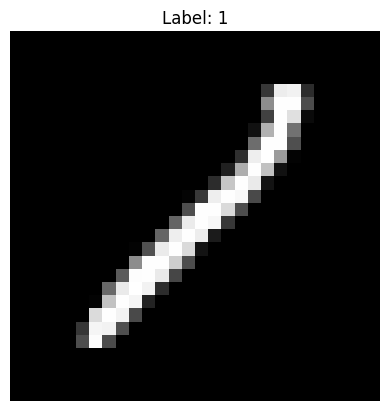

In [5]:
plt.imshow(images[0].squeeze(), cmap="gray")
plt.title(f"Label: {labels[0].item()}")
plt.axis("off")
plt.show()

In [6]:
class ANN(nn.Module):
    def __init__(self,num_features):
        super().__init__()
        self.model = nn.Sequential(
            nn.Flatten(),
            nn.Linear(num_features,128),
            nn.ReLU(),
            nn.Linear(128,64),
            nn.ReLU(),
            nn.Linear(64,10)
        )

    def forward(self,x):
        return self.model(x)

In [7]:
epochs = 100
learning_rate = 0.1

In [8]:
#initiate model
model = ANN(28 * 28)

#loss function
criterion = nn.CrossEntropyLoss()

#optimizer
optimizer = optim.SGD(model.parameters(), lr=learning_rate)

In [9]:
#Trainig Loop

for epoch in range(epochs):

     total_loss = 0
     for images, labels in train_loader:
       # 1. Forward pass
        outputs = model(images)
        # 2. Calculate loss
        loss = criterion(outputs, labels)

        #clear gradient
        optimizer.zero_grad()

        # 3. Backpropagation
        loss.backward()

        # 4. Update weights
        optimizer.step()

        total_loss += loss.item()


     avg_loss = total_loss / len(train_loader)
     print(f"Epoch {epoch+1}/{epochs}, Loss: {avg_loss:.4f}")

Epoch 1/100, Loss: 0.4983
Epoch 2/100, Loss: 0.1957
Epoch 3/100, Loss: 0.1358
Epoch 4/100, Loss: 0.1037
Epoch 5/100, Loss: 0.0830
Epoch 6/100, Loss: 0.0694
Epoch 7/100, Loss: 0.0577
Epoch 8/100, Loss: 0.0496
Epoch 9/100, Loss: 0.0416
Epoch 10/100, Loss: 0.0360
Epoch 11/100, Loss: 0.0317
Epoch 12/100, Loss: 0.0269
Epoch 13/100, Loss: 0.0225
Epoch 14/100, Loss: 0.0196
Epoch 15/100, Loss: 0.0168
Epoch 16/100, Loss: 0.0143
Epoch 17/100, Loss: 0.0120
Epoch 18/100, Loss: 0.0098
Epoch 19/100, Loss: 0.0080
Epoch 20/100, Loss: 0.0065
Epoch 21/100, Loss: 0.0057
Epoch 22/100, Loss: 0.0044
Epoch 23/100, Loss: 0.0036
Epoch 24/100, Loss: 0.0028
Epoch 25/100, Loss: 0.0025
Epoch 26/100, Loss: 0.0021
Epoch 27/100, Loss: 0.0019
Epoch 28/100, Loss: 0.0016
Epoch 29/100, Loss: 0.0015
Epoch 30/100, Loss: 0.0014
Epoch 31/100, Loss: 0.0012
Epoch 32/100, Loss: 0.0011
Epoch 33/100, Loss: 0.0011
Epoch 34/100, Loss: 0.0010
Epoch 35/100, Loss: 0.0009
Epoch 36/100, Loss: 0.0009
Epoch 37/100, Loss: 0.0008
Epoch 38/1

In [10]:
model.eval()

correct = 0
total = 0

with torch.no_grad():
    for images, labels in test_loader:
        outputs = model(images)

        _, predicted = torch.max(outputs, 1)

        total += labels.size(0)
        correct += (predicted == labels).sum().item()

accuracy = 100 * correct / total

print(f"Test Accuracy: {accuracy:.2f}%")

Test Accuracy: 97.96%


In [11]:
torch.save(model.state_dict(), "mnist_ann.pth")